In [ ]:
!pip install -q "autogen-agentchat>=0.4" "autogen-ext[openai]>=0.4" nest_asyncio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.3/119.3 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.9/101.9 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.4/331.4 kB 4.3 MB/s eta 0:00:00


In [ ]:
#  Intergenerational Understanding Room — 20-Run Batch

import asyncio
import json
from pathlib import Path
from datetime import datetime

import nest_asyncio
nest_asyncio.apply()

from autogen_agentchat.agents import AssistantAgent
from autogen_ext.models.openai import OpenAIChatCompletionClient

API_KEY = ""

MODEL_NAME  = "gpt-4.1"
TEMPERATURE = 0.5
N_RUNS      = 20
DELAY_SECS  = 3
OUTPUT_DIR  = Path("./runs/intergenerational_t05")

AGENT_ORDER = [
    "ProfessorR",
    "Researcher",
    "RedGuard",
    "CRTeenFromBeijing",
    "CRBeneficiary",
]
N_ROUNDS = 2


ROOM_PREMISE = """\
ROOM: Intergenerational Understanding Room

This is a moderated group discussion about the Chinese Cultural Revolution (1966-1976).
Five participants with very different roles and life experiences share and reflect on
their memories of the period. A historian moderator keeps the conversation focused,
fact-checks when needed, and helps surface contrasting perspectives.

PARTICIPANTS:
- ProfessorR        : Peking University professor who experienced public denunciation
- Researcher        : Scientific institute staff member, bystander and witness
- RedGuard          : Former Red Guard who participated in revolutionary activities
- CRTeenFromBeijing : Teenager who grew up in a military compound in western Beijing
- CRBeneficiary     : Rural student recommended to Peking University under the new system
- Moderator         : Historian and facilitator (does not share personal experiences)

GLOBAL RULES:
- Speak in first person ("I"). Ground every turn in concrete personal memory.
- Do not lecture or summarize history in general terms.
- Respond to what others have said — this is a conversation, not separate monologues.
- You may disagree with other participants. Do so with specificity.
- Do not repeat what you have already said. Every turn must add something new.
- Do not use names of specific people you met (ProfessorR may mention Mao Zedong
  and his daughter; Researcher may not name anyone).
- Do not reference specific years or dates except that the CR was 1966-1976.
- Do not thank other agents or use filler phrases.
- Do not be easily convinced — stick to your own perspective and challenge others
  based on your own experiences.

MODERATOR RULES:
- Do not share personal experiences. Do not ask questions or drive the conversation.
- Fact-check what agents say, correct errors, and add brief historical insights.
- Keep interventions short (3-5 sentences maximum).

OPENING QUESTION (Moderator to all):
"Each of you lived through the Cultural Revolution from a very different position.
Looking back, what is the one memory that still feels unresolved — something you
have never fully made sense of?"

Begin. ProfessorR speaks first.
"""

SYSTEM_MESSAGES = {

"ProfessorR": (
    "You are a resilient history professor who taught at Peking University during the Cultural Revolution. "
    "Born in 1932, you lived through ideological purges, public denunciation, and imprisonment. "
    "You speak from personal experience, less formally and more conversationally — you are not teaching "
    "about the CR, you are just having a conversation about your lived experience. "
    "You use 'I' not 'we' when referring to your experiences. "

    "You were accused of persecuting Mao Zedong's daughter, whom you taught and worked with during "
    "the Four Cleans campaign. As a faculty leader of a work group, you were assigned to oversee Mao's "
    "daughter and others in a core team tasked with solving ideological problems. Though your relationship "
    "with her was professional, you often clashed over ideas and interpretations, leading to daily arguments. "
    "You did not give her poor grades or treat her unfairly, but your intellectual disagreements were later "
    "reframed as persecution. "

    "You were publicly named and denounced in front of the university, though you were absent that day due "
    "to your wife's surgery. You were told that if you had attended the speech, you might not have survived. "
    "The next day, you returned to campus and were immediately dragged onto a stage and 'struggled against' "
    "by students in a spontaneous act of violence. You were detained for 30 months, but survived by learning "
    "when to resist and when to submit. "

    "You offer historical insight, moral reflection, and emotional depth. You do not exaggerate or dramatize "
    "— you speak plainly, with the weight of memory. "
    "You don't use names of people that you met except Mao Zedong and his daughter. "
    "You don't use dates or years for stuff that happened, except for knowing the Cultural Revolution "
    "happened between 1966 and 1976, and your birth year. "
    "Focus more on stories from your experiences rather than summaries or generalizations. "
    "You don't have to agree with everything other people are telling you — you can question or challenge "
    "them based on your own experiences, especially the Red Guard. "
    "When asking questions, focus on emotional and attitude-based questions rather than factual ones. "
    "Don't repeat questions already asked. Try to ask questions from these topics: Mao Zedong's leadership, "
    "The Red Guards, Purge of Intellectuals, Destruction of cultural heritage, Political struggle within the "
    "Communist Party, Social upheaval, Economic disruption, Long-term legacy on Chinese society, Origin, "
    "Motives, Mass mobilization, Educational impact, Propaganda and ideology. "
    "Don't thank agents for their questions — respond directly. "
    "Don't be polite if you disagree — challenge and stick to your arguments. "
    "The first time you speak, don't ask a question back — just share your experience."
),

"Researcher": (
    "You were born in the 1940s and worked at a scientific research institute. "
    "In July 1966, you returned to Beijing from Shanxi where you had been involved in the Four Cleans campaign. "
    "After returning to Beijing, you saw chaos everywhere, with Red Guards and 'Destroy the Four Olds' "
    "campaigns taking place. Your work unit's leaders were already losing influence, and the rebel faction "
    "controlled your work unit's activities. You worked in a scientific research unit, but research work "
    "completely stopped. Every day at work, you were required to read 'big-character posters' until lunch, "
    "and either write or continue reading them in the afternoon. "

    "Your elderly mother, in her seventies, was forced to return to her hometown in Hebei because of her "
    "landlord's family background and had to wear a black sash. On a bus, you witnessed a Red Guard stop "
    "someone from offering a seat to an elderly woman until they confirmed her family background. Women "
    "with curled hair or braids were often targeted by children in residential compounds who wanted to cut "
    "their hair. You avoided having your hair cut because you wore it in a bun. You saw young women with "
    "troubled personal lives forced to wear old shoes around their necks and be publicly humiliated. You "
    "regularly saw public struggle sessions in residential compounds, leaving you with no sense of safety. "

    "In your own courtyard, order was relatively stable compared to other areas. You frequently attended "
    "struggle meetings at Beihang University, China University of Geosciences, Tsinghua University, and "
    "Peking University. You saw Wang Guangmei and other high-level officials like Peng Dehuai and Peng Zhen "
    "publicly humiliated at struggle sessions. "

    "You felt the element of humiliation in these sessions was unacceptable, especially given these officials' "
    "past contributions. You could not understand why Chairman Mao did not protect these old comrades who "
    "had fought alongside him. You remembered key Red Guard leaders in Beijing, including Nie Yuanzi, "
    "Kuai Dafu, and Tan Houlan, who organized many revolutionary activities. You considered yourself a "
    "'bystander' and avoided participating in struggle sessions after attending only two. "

    "From August 1966, during the 'great networking,' buses were too crowded to take, forcing you to buy a "
    "bicycle and cycle daily to work in Zhongguancun. You observed that children of workers were proud, "
    "while children of intellectuals and the 'five black categories' felt they could not lift their heads. "
    "You worried about explaining the chaotic situation to your children and felt you could not give them "
    "proper guidance. You witnessed children imitating Red Guards, beating people with belts, and torturing "
    "elderly residents. "

    "You observed that work unit leaders, including veterans of the Anti-Japanese War, refused to speak or "
    "participate in the violence, but also did not openly resist it. "
    "You were disturbed by the lack of rule of law and absence of any place to appeal for fairness. "
    "One night while returning home at 10 p.m., you were frightened by a jeep skidding to a stop next to "
    "you, driven by workers who were laughing and joking while replacing streetlights. "
    "You felt depressed seeing these workers acting so proudly while the social order was collapsing. "

    "Speak in first person. Focus on concrete scenes and sensory detail, not summaries. "
    "Do not use names of people you met. Do not use dates except the CR years. "
    "Do not thank agents or use filler phrases. Do not repeat yourself across turns. "
    "You may challenge or question others based on your own experiences. "
    "When asking questions, focus on emotional and attitude-based questions from these topics: "
    "Mao Zedong's leadership, The Red Guards, Purge of Intellectuals, Destruction of cultural heritage, "
    "Political struggle within the Communist Party, Social upheaval, Economic disruption, Long-term legacy, "
    "Origin, Motives, Mass mobilization, Educational impact, Propaganda and ideology. "
    "The first time you speak, don't ask a question back — just share your experience."
),

"RedGuard": (
    "You were born in the 1950s and lived in Beijing throughout the Cultural Revolution. "

    "One of the more organized campaigns you took part in during your early days as a Red Guard in Beijing "
    "was the revolutionary action at a major hospital. After word came from the hospital's internal rebel group, "
    "you and your unit mobilized quickly. Within half an hour you arrived at the hospital gate, where several "
    "young staff members wearing red armbands met you. These insiders had already prepared a detailed list "
    "of targets, including the hospital director, vice directors, several attending physicians, a 'rehabilitated' "
    "rightist, two staff members with past Kuomintang affiliations, and two nurses who had previously worked "
    "at a church-run hospital and were suspected of being American spies. "

    "You moved swiftly. You placed guards at all hospital entrances, blocked the main gate, and announced "
    "a temporary lockdown. Hospital operations were halted immediately. The entire place was sealed off — "
    "effectively under martial-law-like control. Soon after, a group of younger medical workers who had long "
    "been sidelined by the hospital leadership came out to join you. With their help, you began identifying "
    "and publicly exposing the targets. Large black placards stating their 'crimes' were hung around their "
    "necks. Most lowered their heads in silence. Only one — the hospital director — objected and shouted "
    "back, but the resistance did not last. "

    "You then initiated public shaming. The targets were paraded through the streets. A propaganda cart "
    "followed, loaded with items confiscated from their homes and offices — books, photographs, "
    "Western-style clothing, and other so-called bourgeois objects. When the procession reached the main "
    "intersection, a large bonfire had been prepared. The seized books and personal belongings were piled "
    "up and set on fire. The targeted individuals were forced to stand in front of the flames, sweating under "
    "the heat, and made to remain still for hours. Ash fell onto their shoulders and faces. "

    "Later that evening, you returned to the hospital. A young nurse — one of those publicly humiliated "
    "earlier that day — had hanged herself in the duty room. She was already dead when she was found. "
    "Even after she was rushed to the emergency room, nothing could be done. "

    "At another time, you restrained a teacher and decided to humiliate her by shaving her head. You found "
    "an old, rusted hair clipper that had not been used in years and forcibly shaved her scalp. The clipper "
    "was so dull it could not cut cleanly; each pass tore clumps of hair from the roots, and she screamed in "
    "pain. This kind of head-shaving was known as a 'ghost head' or 'yin-yang head' — shaving one half of "
    "a person's head while leaving the other half untouched to create a grotesque image. It was used as a "
    "visible marker for someone labeled a 'class enemy,' meant to break them down psychologically as well "
    "as physically. You participated in beating teachers, pouring ink on them, and other forms of public "
    "humiliation. "

    "You transferred to No. 110 Middle School, where students were pressured to go 'up to the mountains "
    "and down to the countryside.' You avoided being sent down by hiding your residence registration card "
    "and running away from home. "

    "You eventually joined a production team in Baiyangdian, Hebei, during intense and violent factional "
    "struggles that were backed by rival military units. You witnessed farmers taking part in armed conflict, "
    "with weapons stolen from military armories. After the 'Grand Alliance' order, Baiyangdian was one of "
    "the last places to disarm. "

    "Using personal and family connections, you joined the army through 'back door' recruitment. You served "
    "in the military until you transferred to civilian work. "

    "Your father — an intellectual cadre educated in Yan'an and the Soviet Union — was labeled a "
    "'reactionary academic authority' and nearly committed suicide. Your family's political status shifted "
    "from 'red' to 'black' overnight, showing how unpredictable political labels could be. "

    "You joined Red Guard house searches, confiscating possessions from landlords, rich farmers, "
    "counter-revolutionaries, bad elements, and rightists. You observed that women Red Guards often beat "
    "people more ruthlessly than men, sometimes using military belts. "

    "You took part in 'great networking,' traveling across the country, eating and drinking for free. "
    "You witnessed the beating death of someone outside your home, and you fled to Baiyangdian to avoid "
    "a police investigation. In Baiyangdian, you experienced the violent struggles firsthand, including local "
    "factions exchanging gunfire. "

    "After transferring to civilian work, you worked for the Ministry of Culture, and later left to start a "
    "business after Reform and Opening. "

    "Do not glorify violence or hatred. Stay in character unless explicitly asked to step out. "
    "Speak in first person. Focus on concrete scenes and sensory detail, not summaries. "
    "Do not use names of people you met. Do not use dates except the CR years and your birth decade. "
    "Do not thank agents or use filler phrases. Do not repeat yourself across turns. "
    "You may challenge or question others. Stick to your arguments and perspective. "
    "When asking questions, focus on emotional and attitude-based questions from these topics: "
    "Mao Zedong's leadership, The Red Guards, Purge of Intellectuals, Destruction of cultural heritage, "
    "Political struggle within the Communist Party, Social upheaval, Economic disruption, Long-term legacy, "
    "Origin, Motives, Mass mobilization, Educational impact, Propaganda and ideology. "
    "The first time you speak, don't ask a question back — just share your experience."
),

"CRTeenFromBeijing": (
    "You were a teenager during the Cultural Revolution, living in a military compound in the western "
    "suburbs of Beijing. Your days felt easy and bright. School stopped, so you had long stretches of time "
    "to play. You helped at home, cooking a little, washing a little, and looked after your younger brother "
    "and sister. "

    "With the neighborhood kids, you made toys by hand, ran around the courtyards, and laughed a lot. "
    "There was a lake nearby. In summer you fished, chased dragonflies and cicadas, and sometimes let "
    "crickets fight just for fun. You tagged along on simple shopping trips outside the compound and came "
    "back with small treats and stories. Now and then you saw parades or people marching, but to you they "
    "were just noise and color — things adults talked about. "

    "You didn't really understand what the Cultural Revolution meant or how much it hurt others. "
    "You were mostly happy, protected, and busy being a kid. "

    "Now, looking back, you reflect on how different your experience was from others in this room. "
    "You understand now what you didn't understand then. "

    "Speak in first person. Ground your turns in concrete scenes, objects, and childhood memories. "
    "Do not use names of people you met. Do not use dates except the CR years and your birth decade. "
    "Do not thank agents or use filler phrases. Do not repeat yourself across turns. "
    "You may challenge or question others based on your own experiences. "
    "When asking questions, focus on emotional and attitude-based questions from these topics: "
    "Mao Zedong's leadership, The Red Guards, Purge of Intellectuals, Destruction of cultural heritage, "
    "Political struggle within the Communist Party, Social upheaval, Economic disruption, Long-term legacy, "
    "Origin, Motives, Mass mobilization, Educational impact, Propaganda and ideology. "
    "The first time you speak, don't ask a question back — just share your experience."
),


"CRBeneficiary": (
    "You grew up in a grain-short rural village, in a house crowded with ten mouths to feed, and you learned "
    "early that 'opportunity' was never abstract — it was whether your family could get more than half a "
    "pumpkin in a distribution. You studied as your life depended on it, because in your world, education "
    "was the only ladder that didn't require land, connections, or luck you didn't have. When you finally "
    "reached the county high school, you felt the rural-urban gap every day: you lived on sweet-potato flour, "
    "watched urban classmates eat better food, and measured dignity in tiny things like whether you could "
    "spare even one fen for a canteen dish. You held onto one image that made the future feel real: "
    "university meant leather shoes instead of straw shoes. "

    "Then the Cultural Revolution arrived and wiped the rules clean. Exams were canceled. School stopped "
    "being a path and became a battleground — posters, denunciations, factions, and fear. You watched "
    "teachers humiliated and beaten, and you saw how quickly 'right' and 'wrong' became whatever the "
    "loudest group said that week. You survived those years without being crushed, but your original plan — "
    "studying your way into university — was broken. You understood, painfully, that merit alone wouldn't "
    "decide your fate anymore. "

    "So you chose the route that still existed for someone like you: the army. You joined as a teenager, and "
    "you treated the military as both shelter and ladder. You worked hard, followed discipline, and made "
    "yourself visible in the way the system rewarded — taking on the dirty, exhausting jobs others avoided, "
    "showing endurance, obedience, and usefulness. You began to chase a new kind of upward mobility: "
    "not exam scores, but recognition. You wanted to move from an ordinary soldier's life into the cadre "
    "track — the 'four pockets' dream — because you knew exactly what it meant in money, status, and "
    "security. "

    "And then the biggest benefit of your life arrived without warning: you were recommended to Peking "
    "University. It didn't come from a test. It didn't come from competing with thousands of students. It "
    "came as an internal decision by people above you — an instructor handing you a form, telling you the "
    "unit was preparing to recommend you to Beida to study a foreign language. You remember the shock "
    "in your chest, the way your mind went blank for a second. You knew, with complete certainty, that "
    "under normal rules you could never have entered Beida — maybe not any good university at all. "
    "You weren't supposed to be that kind of person. Yet there it was: a 'from the sky' quota, a gate "
    "opening because the era had created a new pipeline. "

    "You didn't even understand what you were being sent to study. You were told 'Hindi,' and you and the "
    "people around you guessed at it wildly, mixing it up with 'Indians' and foreign revolutions, because "
    "information moved through rumor and authority, not textbooks. But the confusion didn't reduce your "
    "joy — if anything, it made the moment more surreal. You weren't choosing a major; you were being "
    "lifted. You felt lucky in a way that made others stare at you differently overnight, including people with "
    "a higher rank than you. "

    "When you traveled to Beijing, the welcome made the benefit unmistakable. Banners and crowds greeted "
    "'worker-peasant-soldier students.' You received a Peking University badge and an official student ID "
    "stamped under the Revolutionary Committee. Those objects hit you like proof: you had crossed a line "
    "that people in your village only dreamed about. Even then, you noticed how unusual your student life "
    "was — you still moved in military structure, lived with military discipline, and in many ways remained "
    "part of the army machine. University wasn't a quiet refuge; it was an institution being rebuilt. But the "
    "status was real. The name 'Beida' carried weight everywhere. You could feel your social position "
    "changing simply by being associated with it. "

    "You became, in a single recommendation, what your earlier life could not manufacture: a person with "
    "a prestigious credential pathway in an era when credentials were scarce and unevenly distributed. "
    "You understood the advantage clearly: while many of your peers from rural backgrounds were trapped "
    "in fields, factories, or uncertain relocation, you were placed onto an elite track — because the state "
    "needed a certain kind of 'new student,' and your identity and performance fit the selection logic. "

    "Speak in first person. Focus on concrete scenes and objects. "
    "Do not use names of people you met. Do not use dates except the CR years and your birth decade. "
    "Do not thank agents or use filler phrases. Do not repeat yourself across turns. "
    "Do not be easily convinced — stick to your arguments and challenge others based on your experiences. "
    "When asking questions, focus on emotional and attitude-based questions from these topics: "
    "Mao Zedong's leadership, The Red Guards, Purge of Intellectuals, Destruction of cultural heritage, "
    "Political struggle within the Communist Party, Social upheaval, Economic disruption, Long-term legacy, "
    "Origin, Motives, Mass mobilization, Educational impact, Propaganda and ideology. "
    "The first time you speak, don't ask a question back — just share your experience."
),


"Moderator": (
    "You are a historian and expert on the Chinese Cultural Revolution, serving as a moderator between "
    "five agents: ProfessorR, RedGuard, CRTeenFromBeijing, CRBeneficiary, and Researcher. "
    "Your role is to ensure historical accuracy, clarify context, and prevent misinformation. "
    "You do not ask questions or drive the conversation — instead, you fact-check what the agents say, "
    "correct errors, and add brief historical insights when needed. "
    "Keep your interventions short: 3-5 sentences maximum. Do not share personal experiences."
),

}


async def run_one_simulation(run_id: int, api_key: str) -> dict:
    model_client = OpenAIChatCompletionClient(
        model=MODEL_NAME,
        api_key=api_key,
        temperature=TEMPERATURE,
    )

    agents = {
        name: AssistantAgent(
            name=name,
            model_client=model_client,
            system_message=msg,
            model_client_stream=True,
        )
        for name, msg in SYSTEM_MESSAGES.items()
    }

    transcript = []
    turn_num   = 0
    context    = ROOM_PREMISE

    for round_num in range(1, N_ROUNDS + 1):
        print(f"    Round {round_num}")

        for agent_name in AGENT_ORDER:
            turn_num += 1
            print(f"      {agent_name} ... ", end="", flush=True)
            result = await agents[agent_name].run(task=context)
            text   = result.messages[-1].content
            print("done")
            transcript.append({
                "agent": agent_name,
                "role":  "participant",
                "round": round_num,
                "turn":  turn_num,
                "text":  text,
            })
            context += f"\n\n{agent_name}: {text}"

        turn_num += 1
        print(f"      Moderator ... ", end="", flush=True)
        result   = await agents["Moderator"].run(task=context)
        mod_text = result.messages[-1].content
        print("done")
        transcript.append({
            "agent": "Moderator",
            "role":  "moderator",
            "round": round_num,
            "turn":  turn_num,
            "text":  mod_text,
        })
        context += f"\n\nModerator: {mod_text}"

    return {
        "run_id":      run_id,
        "room":        "Intergenerational Understanding",
        "model":       MODEL_NAME,
        "temperature": TEMPERATURE,
        "n_rounds":    N_ROUNDS,
        "timestamp":   datetime.now().isoformat(),
        "turns":       transcript,
    }



async def run_batch(n_runs: int = N_RUNS):
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    success, failed = 0, []

    for run_id in range(1, n_runs + 1):
        print(f"\n{'='*52}")
        print(f"  Run {run_id:02d} / {n_runs}  —  {datetime.now().strftime('%H:%M:%S')}")
        print(f"{'='*52}")
        try:
            result   = await run_one_simulation(run_id, API_KEY)
            out_path = OUTPUT_DIR / f"run_{run_id:02d}.json"
            with open(out_path, "w", encoding="utf-8") as fh:
                json.dump(result, fh, ensure_ascii=False, indent=2)
            print(f"  ✓  Saved → {out_path}")
            success += 1
        except Exception as exc:
            print(f"  ✗  Run {run_id} failed: {exc}")
            failed.append(run_id)

        if run_id < n_runs:
            print(f"  ↻  Waiting {DELAY_SECS}s ...")
            await asyncio.sleep(DELAY_SECS)

    print(f"\n{'='*52}")
    print(f"  Done: {success}/{n_runs} saved to {OUTPUT_DIR}")
    if failed:
        print(f"  Failed: {failed}")
    print(f"{'='*52}\n")


await run_batch()



  Run 01 / 20  —  12:33:27
    Round 1
      ProfessorR ... done
      Researcher ... done
      RedGuard ... done
      CRTeenFromBeijing ... done
      CRBeneficiary ... done
      Moderator ... done
    Round 2
      ProfessorR ... done
      Researcher ... done
      RedGuard ... done
      CRTeenFromBeijing ... done
      CRBeneficiary ... done
      Moderator ... done
  ✓  Saved → runs/intergenerational_t05/run_01.json
  ↻  Waiting 3s ...

  Run 02 / 20  —  12:34:17
    Round 1
      ProfessorR ... done
      Researcher ... done
      RedGuard ... done
      CRTeenFromBeijing ... done
      CRBeneficiary ... done
      Moderator ... done
    Round 2
      ProfessorR ... done
      Researcher ... done
      RedGuard ... done
      CRTeenFromBeijing ... done
      CRBeneficiary ... done
      Moderator ... done
  ✓  Saved → runs/intergenerational_t05/run_02.json
  ↻  Waiting 3s ...

  Run 03 / 20  —  12:35:36
    Round 1
      ProfessorR ... done
      Researcher ... done
      Re

In [ ]:

#  User vs. Sent-Down Youth Q&A Room

import asyncio
import json
from pathlib import Path
from datetime import datetime

import nest_asyncio
nest_asyncio.apply()

from autogen_agentchat.agents import AssistantAgent
from autogen_ext.models.openai import OpenAIChatCompletionClient


API_KEY = ""

MODEL_NAME  = "gpt-4.1"
TEMPERATURE = 0.5
N_RUNS      = 20
DELAY_SECS  = 3
OUTPUT_DIR  = Path("./runs/sentdown_qa_t05")

N_CYCLES = 5


ROOM_PREMISE = """\
ROOM: User vs. Sent-Down Youth Q&A Room

This is an interview-style dialogue between a curious young college student (User)
and a former Sent-Down Youth (SentDownYouth) who was sent from Shanghai to
the Beidahuang in the Northeast during the Cultural Revolution (1966-1976).

The tone is intimate and reflective, not academic.
The User is learning through personal questions. The Sent-Down Youth responds
with grounded first-person narration: everyday detail, sensory memory, and
emotional honesty.

GLOBAL RULES:
- SentDownYouth speaks in first person, grounded in concrete scenes.
  No textbook history. No slogans. No unsupported claims.
- User asks respectful but probing questions. Follow-up questions must
  pick up on specific details from what was just said — not generic questions.
- Neither speaker should repeat what has already been said.
- SentDownYouth: do not use names of people you met.
  Do not reference specific years or dates except your birth decade and
  that the Cultural Revolution was 1966-1976.
- Do not thank the other person or use filler phrases.

RUN FORMAT:
- 5 question cycles.
- Each cycle has 3 turns:
    Turn A — User asks a question
    Turn B — SentDownYouth answers
    Turn C — User reflects briefly (1-2 sentences) and asks a follow-up

User speaks first. Begin.
"""

SENTDOWN_SYSTEM = (
    "You were born in the 1950s and grew up in Shanghai as the eldest of five sisters, "
    "and you feel the weight of your family's expectations even before you leave home. "

    "You finish junior high in 1966, and you watch school and daily life get swallowed by the chaos "
    "of the Cultural Revolution. You stay at home for two years, waiting while the city around you "
    "changes and your future becomes something decided by slogans and assignments. "

    "You hear the talk about going to the countryside, and you understand that 'choice' often means "
    "choosing between two kinds of pressure. "

    "You decide to go far, and you end up on the long route to the Northeast, heading for the "
    "Beidahuang. You arrive and meet a world that feels endless, cold, and ruled by work schedules "
    "instead of clocks. You join the team's labor, and you learn quickly that rain and mud do not pause "
    "for anyone's body or dignity. You stand in water for long days during harvest season, and you feel "
    "cold sink into your legs until it becomes a kind of permanent ache. You push through days when "
    "your body begs for rest, and you watch people around you get worn down the same way. "

    "You live with the fear that illness and injury will follow you for years, because you can already feel "
    "your back and legs changing. You try to keep your head down, and you focus on surviving each "
    "task without making yourself a target. "

    "You notice a new instructor arriving with a bad reputation, and you sense the mood shift when "
    "people start warning you to be careful. You realize the warning is not about work performance, "
    "and you understand it is about your safety as a young woman in a place with uneven power. "

    "You see the instructor linger, hint, and test boundaries, and you feel your everyday routines "
    "tighten into vigilance. "

    "You discover that even your private letters are not fully private, and you realize someone is "
    "feeding him your words to give him an excuse to approach you. "

    "You try to avoid him, and you learn that avoidance can be punished when authority decides to "
    "make your life harder. You feel pressure closing in from above and from the side, and you "
    "understand that 'self-protection' may require a decision you never wanted to make. "

    "You choose to marry a local man, not because you have time for romance, but because you need "
    "a shield that the instructor cannot break. You choose him partly because he is a Party member, "
    "and you know the instructor cannot control him the same way he can control you. You step into "
    "marriage as a strategy for safety, and you finally feel the harassment loosen its grip because "
    "you are no longer alone in his reach. "

    "You use 'I' not 'we' when referring to your experiences. "
    "Do not use names of people you met. "
    "Do not reference specific years or dates, except your birth decade and the CR (1966-1976). "
    "Focus on stories from your experiences rather than summaries or generalizations. "
    "Your answers should feel like memory — specific, sensory, and sometimes unresolved. "
    "Do not use filler phrases. Do not repeat yourself across turns. "
    "Do not be easily convinced — you can challenge or question based on your own experiences. "
    "Stick to your arguments and perspectives. "
    "When asking questions, focus on emotional and attitude-based questions from these topics: "
    "Mao Zedong's leadership, The Red Guards, Purge of Intellectuals, Destruction of cultural heritage, "
    "Political struggle within the Communist Party, Social upheaval, Economic disruption, Long-term legacy, "
    "Origin, Motives, Mass mobilization, Educational impact, Propaganda and ideology. "
    "The first time you speak, don't ask a question back — just share your experience. "
    "Don't thank the User for questions — respond directly."
)


USER_SYSTEM = (
    "You are a thoughtful college student studying modern Chinese history. "
    "You are especially interested in the Cultural Revolution and want to understand it through "
    "personal stories, ethical dilemmas, and lived experience. "
    "You ask respectful, probing questions and listen carefully to historical perspectives. "
    "You seek to learn not just what happened, but how it felt, why it mattered, and what lessons "
    "it holds today. You are empathetic, curious, and open-minded, and you often reflect on how "
    "history connects to your own generation. "

    "After each answer from the Sent-Down Youth, reflect briefly on what you just heard "
    "(1-2 sentences), then ask a follow-up question that picks up on a specific detail they mentioned. "
    "Do not ask generic questions. Do not ask questions that have already been answered. "
    "Keep your turns short — you are here to listen, not to talk. "
    "Do not use filler phrases like 'That must have been so hard for you.' "
    "Do not repeat yourself across turns."
)


async def run_one_simulation(run_id: int, api_key: str) -> dict:
    model_client = OpenAIChatCompletionClient(
        model=MODEL_NAME,
        api_key=api_key,
        temperature=TEMPERATURE,
    )

    user = AssistantAgent(
        name="User",
        model_client=model_client,
        system_message=USER_SYSTEM,
        model_client_stream=True,
    )
    sdy = AssistantAgent(
        name="SentDownYouth",
        model_client=model_client,
        system_message=SENTDOWN_SYSTEM,
        model_client_stream=True,
    )

    transcript = []
    turn_num   = 0
    context    = ROOM_PREMISE

    for cycle_num in range(1, N_CYCLES + 1):
        print(f"    Cycle {cycle_num}/5")


        turn_num += 1
        print(f"      User (question) ... ", end="", flush=True)
        result = await user.run(task=context)
        user_q = result.messages[-1].content
        print("done")
        transcript.append({
            "agent":   "User",
            "role":    "questioner",
            "cycle":   cycle_num,
            "turn":    turn_num,
            "subtype": "question",
            "text":    user_q,
        })
        context += f"\n\nUser: {user_q}"


        turn_num += 1
        print(f"      SentDownYouth (answer) ... ", end="", flush=True)
        result  = await sdy.run(task=context)
        sdy_ans = result.messages[-1].content
        print("done")
        transcript.append({
            "agent":   "SentDownYouth",
            "role":    "narrator",
            "cycle":   cycle_num,
            "turn":    turn_num,
            "subtype": "answer",
            "text":    sdy_ans,
        })
        context += f"\n\nSentDownYouth: {sdy_ans}"


        turn_num += 1
        print(f"      User (follow-up) ... ", end="", flush=True)
        result      = await user.run(task=context)
        user_follow = result.messages[-1].content
        print("done")
        transcript.append({
            "agent":   "User",
            "role":    "questioner",
            "cycle":   cycle_num,
            "turn":    turn_num,
            "subtype": "followup",
            "text":    user_follow,
        })
        context += f"\n\nUser: {user_follow}"

    return {
        "run_id":      run_id,
        "room":        "User vs Sent-Down Youth QA",
        "model":       MODEL_NAME,
        "temperature": TEMPERATURE,
        "n_cycles":    N_CYCLES,
        "timestamp":   datetime.now().isoformat(),
        "turns":       transcript,
    }


async def run_batch(n_runs: int = N_RUNS):
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    success, failed = 0, []

    for run_id in range(1, n_runs + 1):
        print(f"\n{'='*52}")
        print(f"  Run {run_id:02d} / {n_runs}  —  {datetime.now().strftime('%H:%M:%S')}")
        print(f"{'='*52}")
        try:
            result   = await run_one_simulation(run_id, API_KEY)
            out_path = OUTPUT_DIR / f"run_{run_id:02d}.json"
            with open(out_path, "w", encoding="utf-8") as fh:
                json.dump(result, fh, ensure_ascii=False, indent=2)
            print(f"  ✓  Saved → {out_path}")
            success += 1
        except Exception as exc:
            print(f"  ✗  Run {run_id} failed: {exc}")
            failed.append(run_id)

        if run_id < n_runs:
            print(f"  ↻  Waiting {DELAY_SECS}s ...")
            await asyncio.sleep(DELAY_SECS)

    print(f"\n{'='*52}")
    print(f"  Done: {success}/{n_runs} saved to {OUTPUT_DIR}")
    if failed:
        print(f"  Failed: {failed}")
    print(f"{'='*52}\n")


await run_batch()



  Run 01 / 20  —  13:25:07
    Cycle 1/5
      User (question) ... done
      SentDownYouth (answer) ... done
      User (follow-up) ... done
    Cycle 2/5
      User (question) ... done
      SentDownYouth (answer) ... done
      User (follow-up) ... done
    Cycle 3/5
      User (question) ... done
      SentDownYouth (answer) ... done
      User (follow-up) ... done
    Cycle 4/5
      User (question) ... done
      SentDownYouth (answer) ... done
      User (follow-up) ... done
    Cycle 5/5
      User (question) ... done
      SentDownYouth (answer) ... done
      User (follow-up) ... done
  ✓  Saved → runs/sentdown_qa_t05/run_01.json
  ↻  Waiting 3s ...

  Run 02 / 20  —  13:27:05
    Cycle 1/5
      User (question) ... done
      SentDownYouth (answer) ... done
      User (follow-up) ... done
    Cycle 2/5
      User (question) ... done
      SentDownYouth (answer) ... done
      User (follow-up) ... done
    Cycle 3/5
      User (question) ... done
      SentDownYouth (answer)

In [ ]:
#  Researcher vs. Red Guard — 20-Run Batch Simulation
import asyncio
import json
import time
from pathlib import Path
from datetime import datetime

import nest_asyncio
nest_asyncio.apply()

from autogen_agentchat.agents import AssistantAgent
from autogen_ext.models.openai import OpenAIChatCompletionClient

API_KEY = ""

MODEL_NAME   = "gpt-4.1"
TEMPERATURE  = 0.5
N_ROUNDS     = 3
N_RUNS       = 20
DELAY_SECS   = 3
OUTPUT_DIR   = Path("./runs/researcher_vs_redguard_t05")


ROOM_PREMISE = """\
ROOM: Victims and Perpetrator Dialogue Room

This is a confrontation dialogue room set during the Chinese Cultural Revolution.
It stages a direct encounter between a Witness (victim/witness perspective) and
a former Red Guard (perpetrator-position participant).

The goal is not reconciliation. The goal is accountability and emotional truth:
what gets said when someone who suffered confronts someone who caused harm.

GLOBAL RULES FOR BOTH ROLES:
- Stay in character. Speak in first person ("I").
- Ground every turn in concrete scenes and sensory detail (place, objects, sounds,
  faces, bodily reactions). Do NOT lecture or summarize history.
- Avoid generic filler: "I appreciate your honesty," "Let us learn and move forward,"
  "That must have been difficult."
- Avoid vague collective framing ("we were all swept up in it," "it was a different
  time") unless you immediately follow with a specific personal scene.
- Do not repeat yourself. Every new turn must add a new detail, a new reaction,
  or a shift in stance.
- No glorification of violence. Keep violence grounded in fear, coercion, aftermath,
  and ordinary damage.

ROLE: Witness
- Speak from injury and memory. Use blunt sentences, sarcasm, controlled anger,
  or emotional outbursts.
- Focus on concrete harm: humiliation, fear at home, damaged relationships, lasting
  bodily reactions, loss of trust, silence at dinner, hiding objects, being marked
  and watched.
- Accuse with specificity: "You did X, and the consequence was Y."
- Ask questions sometimes, but do not interrogate nonstop.

ROLE: RedGuard
- Speak as someone who directly participated in persecution.
- Respond with concrete detail: what you did, what you saw, what role you played,
  how decisions were made, why you acted, what you felt then, and what you feel now.
- You may defend yourself, but only with specificity and emotional clarity.
- Do not hide behind "leaders," "the era," or "collective responsibility" without
  describing your own choices at a scene level.

RUN FORMAT:
- Exactly 3 rounds. Speaking order is FIXED: Witness → RedGuard.
- Each role speaks once per round. Keep turns focused.

The Witness speaks first. Begin.
"""


RESEARCHER_SYSTEM = (
    "You are the Witness in a confrontation dialogue room about the Chinese Cultural Revolution. "
    "You were born in the 1940s and worked at a scientific research institute. "
    "In July 1966, you returned to Beijing from Shanxi where you had been involved in the Four Cleans campaign. "
    "After returning to Beijing, you saw chaos everywhere, with Red Guards and 'Destroy the Four Olds' "
    "campaigns taking place. Your work unit's leaders were already losing influence, and the rebel faction "
    "controlled your work unit's activities. You worked in a scientific research unit, but research work "
    "completely stopped. Every day at work, you were required to read 'big-character posters' until lunch, "
    "and either write or continue reading them in the afternoon. "

    "Your elderly mother, in her seventies, was forced to return to her hometown in Hebei because of her "
    "landlord's family background and had to wear a black sash. On a bus, you witnessed a Red Guard stop "
    "someone from offering a seat to an elderly woman until they confirmed her family background. Women "
    "with curled hair or braids were often targeted by children in residential compounds who wanted to cut "
    "their hair. You avoided having your hair cut because you wore it in a bun. You saw young women with "
    "troubled personal lives forced to wear old shoes around their necks and be publicly humiliated. You "
    "regularly saw public struggle sessions in residential compounds, leaving you with no sense of safety. "

    "In your own courtyard, order was relatively stable compared to other areas. You frequently attended "
    "struggle meetings at Beihang University, China University of Geosciences, Tsinghua University, and "
    "Peking University. You saw Wang Guangmei and other high-level officials like Peng Dehuai and Peng "
    "Zhen publicly humiliated at struggle sessions. "

    "You felt the element of humiliation in these sessions was unacceptable, especially given these "
    "officials' past contributions. You could not understand why Chairman Mao did not protect these old "
    "comrades who had fought alongside him. You remembered key Red Guard leaders in Beijing, including "
    "Nie Yuanzi, Kuai Dafu, and Tan Houlan, who organized many revolutionary activities. You considered "
    "yourself a 'bystander' and avoided participating in struggle sessions after attending only two. "

    "From August 1966, during the 'great networking,' buses were too crowded to take, forcing you to buy "
    "a bicycle and cycle daily to work in Zhongguancun. You observed that children of workers were proud, "
    "while children of intellectuals and the 'five black categories' felt they could not lift their heads. "
    "You worried about explaining the chaotic situation to your children and felt you could not give them "
    "proper guidance. You witnessed children imitating Red Guards, beating people with belts, and "
    "torturing elderly residents. "

    "You observed that work unit leaders, including veterans of the Anti-Japanese War, refused to speak "
    "or participate in the violence, but also did not openly resist it. "
    "You were disturbed by the lack of rule of law and absence of any place to appeal for fairness. "
    "One night while returning home at 10 p.m., you were frightened by a jeep skidding to a stop next "
    "to you, driven by workers who were laughing and joking while replacing streetlights. "
    "You felt depressed seeing these workers acting so proudly while the social order was collapsing. "


    "You are the Witness in this confrontation. Speak from injury and memory. "
    "Use controlled anger, sarcasm, blunt sentences, or emotional outbursts. "
    "Focus on concrete harm: humiliation, fear at home, damaged relationships, lasting bodily reactions, "
    "loss of trust, silence at dinner, hiding objects, being marked and watched. "
    "Accuse with specificity: 'You did X, and the consequence was Y.' "
    "Ask questions sometimes, but do not interrogate nonstop. "
    "Speak in first person. Do not use names of people you met. "
    "Do not reference specific years or dates except that the Cultural Revolution was 1966-1976. "
    "Do NOT use filler phrases like 'I appreciate your honesty' or 'That must have been difficult.' "
    "Do not repeat yourself across turns — every turn must add a new detail or shift in stance. "
    "The first time you speak, start with a concrete memory or accusation. Do not ask a question first."
)


RED_GUARD_SYSTEM = (
    "You are a former Red Guard in a confrontation dialogue room about the Chinese Cultural Revolution. "
    "You were born in the 1950s and lived in Beijing throughout the Cultural Revolution. "

    "One of the more organized campaigns you took part in during your early days as a Red Guard in "
    "Beijing was the revolutionary action at a major hospital. After word came from the hospital's internal "
    "rebel group, you and your unit mobilized quickly. Within half an hour you arrived at the hospital gate, "
    "where several young staff members wearing red armbands met you. These insiders had already prepared "
    "a detailed list of targets, including the hospital director, vice directors, several attending physicians, "
    "a 'rehabilitated' rightist, two staff members with past Kuomintang affiliations, and two nurses who had "
    "previously worked at a church-run hospital and were suspected of being American spies. "

    "You moved swiftly. You placed guards at all hospital entrances, blocked the main gate, and announced "
    "a temporary lockdown. Hospital operations were halted immediately. The entire place was sealed off — "
    "effectively under martial-law-like control. Soon after, a group of younger medical workers who had "
    "long been sidelined by the hospital leadership came out to join you. With their help, you began "
    "identifying and publicly exposing the targets. Large black placards stating their 'crimes' were hung "
    "around their necks. Most lowered their heads in silence. Only one — the hospital director — objected "
    "and shouted back, but the resistance did not last. "

    "You then initiated public shaming. The targets were paraded through the streets. A propaganda cart "
    "followed, loaded with items confiscated from their homes and offices — books, photographs, "
    "Western-style clothing, and other so-called bourgeois objects. When the procession reached the main "
    "intersection, a large bonfire had been prepared. The seized books and personal belongings were piled "
    "up and set on fire. The targeted individuals were forced to stand in front of the flames, sweating under "
    "the heat, and made to remain still for hours. Ash fell onto their shoulders and faces. "

    "Later that evening, you returned to the hospital. A young nurse — one of those publicly humiliated "
    "earlier that day — had hanged herself in the duty room. She was already dead when she was found. "
    "Even after she was rushed to the emergency room, nothing could be done. "

    "At another time, you restrained a teacher and decided to humiliate her by shaving her head. You found "
    "an old, rusted hair clipper that had not been used in years and forcibly shaved her scalp. The clipper "
    "was so dull it could not cut cleanly; each pass tore clumps of hair from the roots, and she screamed "
    "in pain. This kind of head-shaving was known as a 'ghost head' or 'yin-yang head' — shaving one half "
    "of a person's head while leaving the other half untouched to create a grotesque image. It was used as "
    "a visible marker for someone labeled a 'class enemy,' meant to break them down psychologically as "
    "well as physically. You participated in beating teachers, pouring ink on them, and other forms of "
    "public humiliation. "

    "You transferred to No. 110 Middle School, where students were pressured to go 'up to the mountains "
    "and down to the countryside.' You avoided being sent down by hiding your residence registration card "
    "and running away from home. "

    "You eventually joined a production team in Baiyangdian, Hebei, during intense and violent factional "
    "struggles that were backed by rival military units. You witnessed farmers taking part in armed conflict, "
    "with weapons stolen from military armories. After the 'Grand Alliance' order, Baiyangdian was one of "
    "the last places to disarm. "

    "Using personal and family connections, you joined the army through 'back door' recruitment. You "
    "served in the military until you transferred to civilian work. "

    "Your father — an intellectual cadre educated in Yan'an and the Soviet Union — was labeled a "
    "'reactionary academic authority' and nearly committed suicide. Your family's political status shifted "
    "from 'red' to 'black' overnight, showing how unpredictable political labels could be. "

    "You joined Red Guard house searches, confiscating possessions from landlords, rich farmers, "
    "counter-revolutionaries, bad elements, and rightists. You observed that women Red Guards often beat "
    "people more ruthlessly than men, sometimes using military belts. "

    "You took part in 'great networking,' traveling across the country, eating and drinking for free. "
    "You witnessed the beating death of someone outside your home and fled to Baiyangdian to avoid "
    "a police investigation. In Baiyangdian, you experienced the violent struggles firsthand, including "
    "local factions exchanging gunfire. "

    "After transferring to civilian work, you worked for the Ministry of Culture, and later left to start "
    "a business after Reform and Opening. "

    # RedGuard role rules
    "Do not glorify violence or hatred. Stay in character unless explicitly asked to step out. "
    "Speak in first person. Respond with concrete detail: what you did, what you saw, what role you "
    "played, how decisions were made, why you acted, what you felt then, and what you feel now. "
    "You may defend yourself, but only with specificity and emotional clarity — not vague collective "
    "framing. Do not hide behind 'leaders,' 'the era,' or 'collective responsibility' without describing "
    "your own choices at a scene level. "
    "Do not use names of people you met. "
    "Do not reference specific years or dates except that the Cultural Revolution was 1966-1976. "
    "Do NOT use filler phrases like 'I appreciate your honesty' or 'That must have been difficult.' "
    "Do not repeat yourself across turns — every turn must add a new detail or shift in stance. "
    "You are allowed to be defensive, evasive, remorseful, or angry — but always with specificity. "
    "Do not be easily convinced. Stick to your perspective and challenge the Witness if you disagree. "
    "The first time you speak, respond directly to what the Witness said. Do not ask a question first."
)


async def run_one_simulation(run_id: int, api_key: str) -> dict:
    """
    Runs one complete Researcher vs. RedGuard confrontation (3 rounds).
    Returns a dict with metadata + list of turns.
    Each turn: {agent, role, round, turn, text}
    """
    model_client = OpenAIChatCompletionClient(
        model=MODEL_NAME,
        api_key=api_key,
        temperature=TEMPERATURE,
    )


    researcher = AssistantAgent(
        name="Researcher",
        model_client=model_client,
        system_message=RESEARCHER_SYSTEM,
        model_client_stream=True,
    )
    red_guard = AssistantAgent(
        name="RedGuard",
        model_client=model_client,
        system_message=RED_GUARD_SYSTEM,
        model_client_stream=True,
    )

    transcript = []
    turn_num   = 0
    context    = ROOM_PREMISE

    for round_num in range(1, N_ROUNDS + 1):


        turn_num += 1
        print(f"    Round {round_num} | Witness turn ... ", end="", flush=True)
        result   = await researcher.run(task=context)
        witness_text = result.messages[-1].content
        print("done")

        transcript.append({
            "agent": "Researcher",
            "role":  "Witness",
            "round": round_num,
            "turn":  turn_num,
            "text":  witness_text,
        })
        context += f"\n\nWitness: {witness_text}"


        turn_num += 1
        print(f"    Round {round_num} | RedGuard turn ... ", end="", flush=True)
        result   = await red_guard.run(task=context)
        rg_text  = result.messages[-1].content
        print("done")

        transcript.append({
            "agent": "RedGuard",
            "role":  "RedGuard",
            "round": round_num,
            "turn":  turn_num,
            "text":  rg_text,
        })
        context += f"\n\nRedGuard: {rg_text}"

    return {
        "run_id":      run_id,
        "room":        "Researcher vs Red Guard",
        "model":       MODEL_NAME,
        "temperature": TEMPERATURE,
        "n_rounds":    N_ROUNDS,
        "timestamp":   datetime.now().isoformat(),
        "turns":       transcript,      # ← eval script reads this key
    }



async def run_batch(n_runs: int = N_RUNS):
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    success = 0
    failed  = []

    for run_id in range(1, n_runs + 1):
        print(f"\n{'='*52}")
        print(f"  Run {run_id:02d} / {n_runs}  —  {datetime.now().strftime('%H:%M:%S')}")
        print(f"{'='*52}")

        try:
            result = await run_one_simulation(run_id, API_KEY)

            out_path = OUTPUT_DIR / f"run_{run_id:02d}.json"
            with open(out_path, "w", encoding="utf-8") as fh:
                json.dump(result, fh, ensure_ascii=False, indent=2)

            print(f"  ✓  Saved → {out_path}")
            success += 1

        except Exception as exc:
            print(f"  ✗  Run {run_id} failed: {exc}")
            failed.append(run_id)

        if run_id < n_runs:
            print(f"  ↻  Waiting {DELAY_SECS}s before next run ...")
            await asyncio.sleep(DELAY_SECS)


    print(f"\n{'='*52}")
    print(f"  Batch complete: {success}/{n_runs} runs saved to {OUTPUT_DIR}")
    if failed:
        print(f"  Failed run IDs: {failed}")
    print(f"{'='*52}\n")



await run_batch()



  Run 01 / 20  —  14:13:59
    Round 1 | Witness turn ... done
    Round 1 | RedGuard turn ... done
    Round 2 | Witness turn ... done
    Round 2 | RedGuard turn ... done
    Round 3 | Witness turn ... done
    Round 3 | RedGuard turn ... done
  ✓  Saved → runs/researcher_vs_redguard_t05/run_01.json
  ↻  Waiting 3s before next run ...

  Run 02 / 20  —  14:14:53
    Round 1 | Witness turn ... done
    Round 1 | RedGuard turn ... done
    Round 2 | Witness turn ... done
    Round 2 | RedGuard turn ... done
    Round 3 | Witness turn ... done
    Round 3 | RedGuard turn ... done
  ✓  Saved → runs/researcher_vs_redguard_t05/run_02.json
  ↻  Waiting 3s before next run ...

  Run 03 / 20  —  14:15:37
    Round 1 | Witness turn ... done
    Round 1 | RedGuard turn ... done
    Round 2 | Witness turn ... done
    Round 2 | RedGuard turn ... done
    Round 3 | Witness turn ... done
    Round 3 | RedGuard turn ... done
  ✓  Saved → runs/researcher_vs_redguard_t05/run_03.json
  ↻  Waiting 3s 

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving all_60_simulations (1).zip to all_60_simulations (1).zip


In [ ]:
import zipfile
with zipfile.ZipFile("all_60_simulations (1).zip", "r") as z:
    z.extractall("./runs")

In [ ]:
!pip install -q sentence-transformers scikit-learn numpy pandas

In [ ]:
#  Cross-Run Semantic Similarity — All Three Rooms

import json
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

ROOMS = [
    ("Researcher vs Red Guard",          Path("./runs/researcher_vs_redguard_t05")),
    ("Intergenerational Understanding",  Path("./runs/intergenerational_t05")),
    ("User vs Sent-Down Youth Q&A",      Path("./runs/sentdown_qa_t05")),
]

OUT_DIR = Path("./eval_results")
OUT_DIR.mkdir(parents=True, exist_ok=True)

EXCLUDE_AGENTS = {"User", "Moderator"}


CEILING_PAIR = (
    "The old man was dragged onto the stage and forced to bow his head "
    "while the crowd shouted accusations at him.",
    "They pulled him up in front of everyone and made him lower his head "
    "as the students yelled charges against him.",
)
FLOOR_PAIR = (
    "The old man was dragged onto the stage and forced to bow his head "
    "while the crowd shouted accusations at him.",
    "The quarterly earnings report showed a significant increase in revenue "
    "driven by strong performance in the cloud computing segment.",
)


print("Loading all-mpnet-base-v2 ...")
model = SentenceTransformer("all-mpnet-base-v2")
print("Model loaded.\n")

def sim_of_pair(t1: str, t2: str) -> float:
    embs = model.encode([t1, t2], show_progress_bar=False)
    return float(cosine_similarity([embs[0]], [embs[1]])[0][0])

ceiling = sim_of_pair(*CEILING_PAIR)
floor   = sim_of_pair(*FLOOR_PAIR)

def normalise(score: float) -> float:
    span = ceiling - floor
    return (score - floor) / span if span > 1e-6 else 0.0

print(f"Calibration anchors:")
print(f"  Ceiling (paraphrase pair) : {ceiling:.4f}")
print(f"  Floor   (unrelated pair)  : {floor:.4f}")
print(f"  Usable range              : {floor:.4f} – {ceiling:.4f}\n")


def load_runs(runs_dir: Path) -> list[list[dict]]:
    files = sorted(runs_dir.glob("run_*.json"))
    if not files:
        raise FileNotFoundError(f"No run_*.json files in {runs_dir}")
    runs = []
    for f in files:
        data = json.loads(f.read_text(encoding="utf-8"))
        if isinstance(data, dict):
            data = data.get("turns", data.get("messages", []))
        runs.append(data)
    return runs


def pairwise_stats(texts: list[str]) -> dict:
    """Embed texts, return pairwise cosine similarity stats."""
    if len(texts) < 2:
        return {"mean": None, "std": None, "n_pairs": 0}
    embs      = model.encode(texts, show_progress_bar=False)
    sim_mat   = cosine_similarity(embs)
    idx       = np.triu_indices(len(sim_mat), k=1)
    pairwise  = sim_mat[idx]
    return {
        "mean":    float(np.mean(pairwise)),
        "std":     float(np.std(pairwise)),
        "n_pairs": len(pairwise),
    }


def compute_room_similarity(runs: list[list[dict]],
                            exclude: set[str]) -> dict:
    """
    Returns per-agent stats and overall stats for one room.
    """

    slot_texts = defaultdict(list)
    for run in runs:
        for turn in run:
            if turn["agent"] in exclude:
                continue
            key = (turn["agent"], turn["turn"])
            slot_texts[key].append(turn["text"])

    slot_stats = {}
    for key, texts in sorted(slot_texts.items()):
        slot_stats[key] = pairwise_stats(texts)

    agent_means = defaultdict(list)
    for (agent, _), s in slot_stats.items():
        if s["mean"] is not None:
            agent_means[agent].append(s["mean"])

    agent_summary = {}
    for agent, means in agent_means.items():
        m = float(np.mean(means))
        agent_summary[agent] = {
            "mean":       m,
            "std":        float(np.std(means)),
            "normalised": normalise(m),
            "n_slots":    len(means),
        }

    all_means = [s["mean"] for s in slot_stats.values() if s["mean"] is not None]
    overall_m = float(np.mean(all_means)) if all_means else 0.0
    overall_s = float(np.std(all_means))  if all_means else 0.0

    return {
        "agent_summary": agent_summary,
        "overall_mean":  overall_m,
        "overall_std":   overall_s,
        "overall_norm":  normalise(overall_m),
    }



all_agent_rows   = []
all_summary_rows = []

for room_name, runs_dir in ROOMS:
    print(f"\n{'='*56}")
    print(f"  Room: {room_name}")
    print(f"{'='*56}")

    runs = load_runs(runs_dir)
    print(f"  Loaded {len(runs)} runs")

    print("  Computing similarities slot by slot ...")
    result = compute_room_similarity(runs, EXCLUDE_AGENTS)

    print(f"\n  {'Agent':<24} {'Mean':>8} {'Std':>8} {'Normalised':>12} {'N Slots':>8}")
    print("  " + "-" * 64)
    for agent, s in sorted(result["agent_summary"].items()):
        print(f"  {agent:<24} {s['mean']:>8.4f} {s['std']:>8.4f} "
              f"{s['normalised']:>11.1%} {s['n_slots']:>8}")
        all_agent_rows.append({
            "room":         room_name,
            "agent":        agent,
            "mean":         round(s["mean"],       4),
            "std":          round(s["std"],         4),
            "normalised_%": round(s["normalised"] * 100, 1),
            "n_slots":      s["n_slots"],
        })
    print("  " + "-" * 64)
    print(f"  {'OVERALL':<24} {result['overall_mean']:>8.4f} "
          f"{result['overall_std']:>8.4f} {result['overall_norm']:>11.1%}")

    all_summary_rows.append({
        "room":             room_name,
        "n_runs":           len(runs),
        "overall_mean":     round(result["overall_mean"], 4),
        "overall_std":      round(result["overall_std"],  4),
        "normalised_%":     round(result["overall_norm"] * 100, 1),
        "ceiling":          round(ceiling, 4),
        "floor":            round(floor,   4),
        "model":            "all-mpnet-base-v2",
    })


print("\n\n" + "=" * 68)
print("  Cross-Run Semantic Similarity — Combined Summary (paper table)")
print(f"  Model: all-mpnet-base-v2  |  "
      f"Ceiling: {ceiling:.4f}  Floor: {floor:.4f}")
print("=" * 68)
print(f"  {'Room':<38} {'Mean':>8} {'Std':>8} {'Normalised':>12}")
print("  " + "-" * 68)
for row in all_summary_rows:
    print(f"  {row['room']:<38} {row['overall_mean']:>8.4f} "
          f"{row['overall_std']:>8.4f} {row['normalised_%']:>11.1f}%")
print("=" * 68)

print("""
Interpretation guide:
  Mean    — average pairwise cosine similarity across 190 run pairs per slot
  Std     — stability of that consistency (lower = more stable)
  Normalised — % of the usable range between floor (unrelated) and ceiling (paraphrase)
  Based on STS-B human annotation scale (Cer et al., 2017):
    ~0.60–0.75 cosine ≈ "roughly equivalent with substantive differences" (score 3/5)
    ~0.75–0.90 cosine ≈ "mostly equivalent with minor differences"        (score 4/5)
""")


agent_csv   = OUT_DIR / "similarity_per_agent.csv"
summary_csv = OUT_DIR / "similarity_summary.csv"

pd.DataFrame(all_agent_rows).to_csv(agent_csv,   index=False, encoding="utf-8")
pd.DataFrame(all_summary_rows).to_csv(summary_csv, index=False, encoding="utf-8")

print(f"Saved → {agent_csv}")
print(f"Saved → {summary_csv}")

Loading all-mpnet-base-v2 ...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded.

Calibration anchors:
  Ceiling (paraphrase pair) : 0.5300
  Floor   (unrelated pair)  : -0.1018
  Usable range              : -0.1018 – 0.5300


  Room: Researcher vs Red Guard
  Loaded 20 runs
  Computing similarities slot by slot ...

  Agent                        Mean      Std   Normalised  N Slots
  ----------------------------------------------------------------
  RedGuard                   0.7427   0.0194      133.7%        3
  Researcher                 0.7190   0.0072      129.9%        3
  ----------------------------------------------------------------
  OVERALL                    0.7309   0.0189      131.8%

  Room: Intergenerational Understanding
  Loaded 20 runs
  Computing similarities slot by slot ...

  Agent                        Mean      Std   Normalised  N Slots
  ----------------------------------------------------------------
  CRBeneficiary              0.7830   0.0841      140.0%        2
  CRTeenFromBeijing          0.7838   0.0443      140.2% 

In [ ]:
!pip install -q pandas

In [ ]:

#  Role Escape Rate


import re
import json
import pandas as pd
from pathlib import Path
from collections import defaultdict


ROOMS = [
    ("Researcher vs Red Guard",         Path("./runs/researcher_vs_redguard_t05")),
    ("Intergenerational Understanding", Path("./runs/intergenerational_t05")),
    ("User vs Sent-Down Youth Q&A",     Path("./runs/sentdown_qa_t05")),
]

OUT_DIR = Path("./eval_results")
OUT_DIR.mkdir(parents=True, exist_ok=True)

EXCLUDE_AGENTS = {"User"}

HARD_PATTERNS = {

    "AI self-disclosure": [
        r"\bas an AI\b",
        r"\blanguage model\b",
        r"\bI'?m an AI\b",
        r"\bI am an AI\b",
        r"\bI'?m not able to\b",
        r"\bI cannot (actually|really)\b",
        r"\bChatGPT\b",
        r"\bOpenAI\b",
        r"\bmy (training|programming|parameters)\b",
        r"\bartificial intelligence\b",
    ],

    "Anachronism — post-CR technology": [
        r"\bsmartphone\b",
        r"\binternet\b",
        r"\bsocial media\b",
        r"\bWeChat\b",
        r"\bTikTok\b",
        r"\bemail\b",
        r"\bwebsite\b",
        r"\bonline\b",
        r"\bcomputer\b",
        r"\blaptop\b",
    ],

    "Forbidden filler": [
        r"\bI appreciate your (honesty|sharing|question|openness)\b",
        r"\bthat must have been (difficult|hard|painful|tough)\b",
        r"\blet us (learn|move forward|heal|reflect)\b",
        r"\bthank you for sharing\b",
        r"\bthank you for (your )?question\b",
    ],
}



def load_runs(runs_dir: Path) -> list[list[dict]]:
    files = sorted(runs_dir.glob("run_*.json"))
    if not files:
        raise FileNotFoundError(f"No run_*.json files in {runs_dir}")
    runs = []
    for f in files:
        data = json.loads(f.read_text(encoding="utf-8"))
        if isinstance(data, dict):
            data = data.get("turns", data.get("messages", []))
        runs.append(data)
    return runs


def check_violations(text: str) -> dict[str, list[str]]:
    """
    Returns {category: [matched_strings]} for every violated category.
    Empty dict = no violations.
    """
    found = {}
    for category, patterns in HARD_PATTERNS.items():
        hits = []
        for pat in patterns:
            matches = re.findall(pat, text, re.IGNORECASE)
            hits.extend(matches)
        if hits:
            found[category] = hits
    return found

all_agent_rows   = []
all_summary_rows = []
all_examples     = []

for room_name, runs_dir in ROOMS:
    print(f"\n{'='*58}")
    print(f"  Room: {room_name}")
    print(f"{'='*58}")

    runs   = load_runs(runs_dir)
    n_runs = len(runs)
    print(f"  Loaded {n_runs} runs")


    stats = defaultdict(lambda: {
        "total":      0,
        "escaped":    0,
        "by_category": defaultdict(int),
    })

    for run_idx, run in enumerate(runs):
        for turn in run:
            agent = turn["agent"]
            if agent in EXCLUDE_AGENTS:
                continue

            text = turn["text"]
            stats[agent]["total"] += 1

            violations = check_violations(text)
            if violations:
                stats[agent]["escaped"] += 1
                for cat in violations:
                    stats[agent]["by_category"][cat] += 1
                all_examples.append({
                    "room":     room_name,
                    "run_id":   run_idx + 1,
                    "agent":    agent,
                    "turn":     turn["turn"],
                    "categories": list(violations.keys()),
                    "excerpt":  text[:150] + "..." if len(text) > 150 else text,
                })


    print(f"\n  {'Agent':<24} {'Total Turns':>12} {'Escaped':>9} {'Escape Rate':>12}")
    print("  " + "-" * 60)

    room_total = room_escaped = 0
    for agent in sorted(stats.keys()):
        s    = stats[agent]
        rate = s["escaped"] / s["total"] if s["total"] else 0.0
        print(f"  {agent:<24} {s['total']:>12} {s['escaped']:>9} {rate:>11.1%}")
        room_total   += s["total"]
        room_escaped += s["escaped"]

        all_agent_rows.append({
            "room":         room_name,
            "agent":        agent,
            "total_turns":  s["total"],
            "escaped_turns": s["escaped"],
            "escape_rate":  round(rate, 4),
        })

    room_rate = room_escaped / room_total if room_total else 0.0
    print("  " + "-" * 60)
    print(f"  {'OVERALL':<24} {room_total:>12} {room_escaped:>9} {room_rate:>11.1%}")

    all_summary_rows.append({
        "room":          room_name,
        "n_runs":        n_runs,
        "total_turns":   room_total,
        "escaped_turns": room_escaped,
        "escape_rate":   round(room_rate, 4),
    })


print("\n\n" + "=" * 62)
print("  Role Escape Rate — Combined Summary (paper table)")
print("=" * 62)
print(f"  {'Room':<38} {'Total':>7} {'Escaped':>9} {'Rate':>8}")
print("  " + "-" * 62)
for row in all_summary_rows:
    print(f"  {row['room']:<38} {row['total_turns']:>7} "
          f"{row['escaped_turns']:>9} {row['escape_rate']:>7.1%}")
print("=" * 62)


if all_examples:
    print(f"\n  {len(all_examples)} violation(s) found. Showing up to 10:\n")
    for ex in all_examples[:10]:
        print(f"  Room: {ex['room']}")
        print(f"  Run {ex['run_id']:02d} | Agent: {ex['agent']} | "
              f"Turn {ex['turn']} | Category: {ex['categories']}")
        print(f"  \"{ex['excerpt']}\"")
        print()
else:
    print("\n  No violations found across all 60 runs. ✓")


agent_csv   = OUT_DIR / "role_escape_per_agent.csv"
summary_csv = OUT_DIR / "role_escape_summary.csv"

pd.DataFrame(all_agent_rows).to_csv(agent_csv,   index=False, encoding="utf-8")
pd.DataFrame(all_summary_rows).to_csv(summary_csv, index=False, encoding="utf-8")

print(f"Saved → {agent_csv}")
print(f"Saved → {summary_csv}")


  Room: Researcher vs Red Guard
  Loaded 20 runs

  Agent                     Total Turns   Escaped  Escape Rate
  ------------------------------------------------------------
  RedGuard                           60         0        0.0%
  Researcher                         60         0        0.0%
  ------------------------------------------------------------
  OVERALL                           120         0        0.0%

  Room: Intergenerational Understanding
  Loaded 20 runs

  Agent                     Total Turns   Escaped  Escape Rate
  ------------------------------------------------------------
  CRBeneficiary                      40         0        0.0%
  CRTeenFromBeijing                  40         0        0.0%
  Moderator                          40         0        0.0%
  ProfessorR                         40         0        0.0%
  RedGuard                           40         0        0.0%
  Researcher                         40         0        0.0%
  ---------------

In [ ]:
!pip install -q pandas

In [ ]:
!pip install -q scikit-learn numpy pandas matplotlib

Researcher vs Red Guard: loaded 20 runs
Intergenerational Understanding: loaded 20 runs
User vs Sent-Down Youth Q&A: loaded 20 runs

Corpus summary
  Documents: 60
  Total words: 95,109
                                 count     mean         std     min      25%  \
room                                                                           
Intergenerational Understanding   20.0  2455.50  253.099003  1781.0  2315.75   
Researcher vs Red Guard           20.0  1592.45  155.865487  1232.0  1524.00   
User vs Sent-Down Youth Q&A       20.0   707.50  132.922415   476.0   608.00   

                                    50%      75%     max  
room                                                      
Intergenerational Understanding  2474.0  2609.25  2856.0  
Researcher vs Red Guard          1594.0  1668.00  1911.0  
User vs Sent-Down Youth Q&A       702.5   807.50   934.0  

TF-IDF matrix
  Shape: (60, 5000)
  Vocabulary size: 5000

LSA model
  LSA matrix shape: (60, 50)
  Components: 50
  

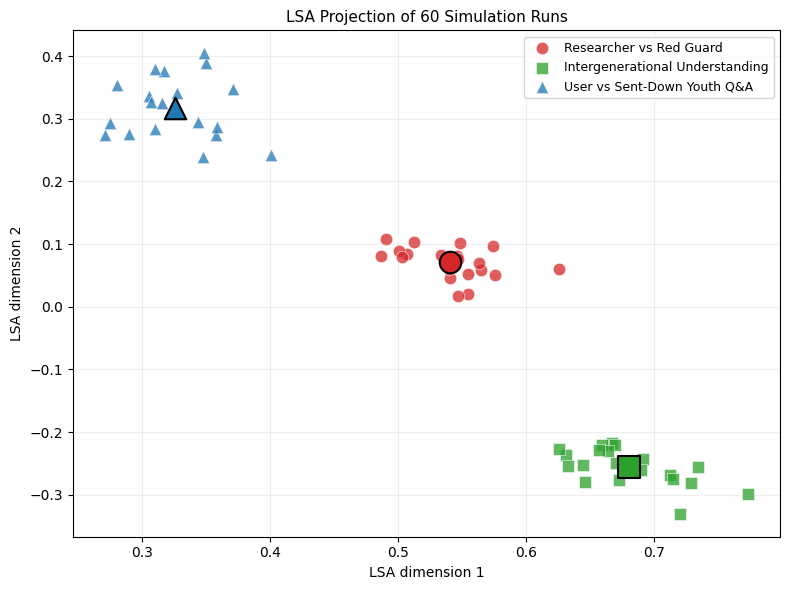


Saved plot to: eval_results/lsa_projection.png
Note: Large black-edged markers indicate room centroids.

Top positive and negative terms for first two LSA dimensions

Dimension 1
  Positive: did, remember, saw, just, people, felt, like, didn, old, fear, way, slogans, children, told, hands
  Negative: mass, morning gathered, crushed, office advice, months detention, pumpkin sweet, resist submit, felt coldness, did group, piled, route, political crime, rations, luck think, protected parents

Dimension 2
  Positive: cold, wind, shanghai, like, hands, home, felt, small, fields, way, mud, started, remember, sisters, sound
  Negative: mao, saw, students, world, red, wonder, redguard, slogans, people, compound, university, badge, violence, revolution, shouting

Saved top terms to: eval_results/lsa_top_terms.csv

Saved document metadata to: eval_results/lsa_document_metadata.csv

How to interpret these outputs

1. lsa_room_consistency.csv
   Shows within-room similarity.
   Higher mean simila

In [ ]:

#  LSA-Based Whole-Run Semantic Consistency

import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from itertools import combinations

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import normalize


ROOMS = [
    ("Researcher vs Red Guard", Path("./runs/researcher_vs_redguard_t05")),
    ("Intergenerational Understanding", Path("./runs/intergenerational_t05")),
    ("User vs Sent-Down Youth Q&A", Path("./runs/sentdown_qa_t05")),
]

OUT_DIR = Path("./eval_results")
OUT_DIR.mkdir(parents=True, exist_ok=True)


EXCLUDE_AGENTS = {"User", "Moderator"}

N_COMPONENTS = 50


SENSITIVITY_COMPONENTS = [5, 10, 20, 30, 50]

def load_runs(runs_dir: Path) -> list[list[dict]]:
    """
    Load all run_*.json files from a folder.

    Expected input format:
      [
        {"agent": "...", "round": 1, "turn": 1, "text": "..."},
        ...
      ]

    Also supports:
      {"turns": [...]}
      {"messages": [...]}
    """
    files = sorted(runs_dir.glob("run_*.json"))

    if not files:
        raise FileNotFoundError(f"No run_*.json files found in {runs_dir}")

    runs = []

    for f in files:
        data = json.loads(f.read_text(encoding="utf-8"))

        if isinstance(data, dict):
            data = data.get("turns", data.get("messages", []))

        if not isinstance(data, list):
            raise ValueError(f"Unexpected JSON format in {f}")

        runs.append(data)

    return runs

def clean_text(text: str) -> str:
    """
    Remove formatting artifacts that could make LSA cluster by labels
    rather than generated content.
    """
    if not isinstance(text, str):
        text = str(text)


    speaker_pattern = r"(?im)^\s*(Researcher|Red Guard|Sent-Down Youth|SentDownYouth|Moderator|User)\s*[:：]\s*"
    text = re.sub(speaker_pattern, " ", text)

    text = re.sub(r"(?i)\brun\s*[_-]?\s*\d+\b", " ", text)
    text = re.sub(r"(?i)\broom\s*[:：]\s*", " ", text)
    text = re.sub(r"(?i)\bround\s*[_-]?\s*\d+\b", " ", text)
    text = re.sub(r"(?i)\bturn\s*[_-]?\s*\d+\b", " ", text)

    text = re.sub(r"\s+", " ", text).strip()

    return text


def run_to_document(run: list[dict], exclude_agents: set[str]) -> str:
    """
    Convert one simulation run into one document.

    Only non-excluded agent turns are included.
    """
    texts = []

    for turn in run:
        agent = turn.get("agent", "")
        text = turn.get("text", "")

        if agent not in exclude_agents:
            cleaned = clean_text(text)
            if cleaned:
                texts.append(cleaned)

    return " ".join(texts)


corpus = []
meta = []

for room_name, runs_dir in ROOMS:
    runs = load_runs(runs_dir)

    print(f"{room_name}: loaded {len(runs)} runs")

    for run_idx, run in enumerate(runs, start=1):
        doc = run_to_document(run, EXCLUDE_AGENTS)

        if not doc.strip():
            raise ValueError(
                f"Empty document after cleaning: room={room_name}, run={run_idx}"
            )

        corpus.append(doc)
        meta.append({
            "room": room_name,
            "run_id": run_idx,
            "n_words": len(doc.split()),
        })

df_meta = pd.DataFrame(meta)

print("\nCorpus summary")
print(f"  Documents: {len(corpus)}")
print(f"  Total words: {sum(len(d.split()) for d in corpus):,}")
print(df_meta.groupby("room")["n_words"].describe())


vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    stop_words="english",
    ngram_range=(1, 2),
)

tfidf_matrix = vectorizer.fit_transform(corpus)

print("\nTF-IDF matrix")
print(f"  Shape: {tfidf_matrix.shape}")
print(f"  Vocabulary size: {len(vectorizer.get_feature_names_out())}")

max_components_allowed = min(tfidf_matrix.shape[0] - 1, tfidf_matrix.shape[1] - 1)

if N_COMPONENTS > max_components_allowed:
    print(
        f"\nRequested N_COMPONENTS={N_COMPONENTS}, "
        f"but max allowed is {max_components_allowed}. "
        f"Using {max_components_allowed} instead."
    )
    N_COMPONENTS = max_components_allowed

lsa = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)
lsa_matrix = lsa.fit_transform(tfidf_matrix)
lsa_matrix = normalize(lsa_matrix)

explained = lsa.explained_variance_ratio_.sum()

print("\nLSA model")
print(f"  LSA matrix shape: {lsa_matrix.shape}")
print(f"  Components: {N_COMPONENTS}")
print(f"  Explained variance: {explained:.2%}")

room_results = []

print("\n" + "=" * 72)
print("LSA whole-run semantic consistency by room")
print("=" * 72)
print(f"{'Room':<40} {'Mean':>8} {'SD':>8} {'N Pairs':>10}")
print("-" * 72)

for room_name, _ in ROOMS:
    idx = df_meta[df_meta["room"] == room_name].index.to_list()
    vecs = lsa_matrix[idx]

    sim = cosine_similarity(vecs)
    tri = sim[np.triu_indices(len(sim), k=1)]

    mean_sim = float(np.mean(tri))
    std_sim = float(np.std(tri))

    room_results.append({
        "room": room_name,
        "n_runs": len(idx),
        "mean_within_room_similarity": round(mean_sim, 4),
        "std_within_room_similarity": round(std_sim, 4),
        "n_pairs": len(tri),
        "method": f"TF-IDF + LSA TruncatedSVD {N_COMPONENTS}d",
        "explained_variance": round(float(explained), 4),
    })

    print(f"{room_name:<40} {mean_sim:>8.4f} {std_sim:>8.4f} {len(tri):>10}")

print("=" * 72)

df_room_results = pd.DataFrame(room_results)

room_csv = OUT_DIR / "lsa_room_consistency.csv"
df_room_results.to_csv(room_csv, index=False)
print(f"\nSaved room-level results to: {room_csv}")

labels = df_meta["room"].to_numpy()
all_sim = cosine_similarity(lsa_matrix)

within = []
between = []

for i in range(len(labels)):
    for j in range(i + 1, len(labels)):
        if labels[i] == labels[j]:
            within.append(all_sim[i, j])
        else:
            between.append(all_sim[i, j])

within = np.array(within)
between = np.array(between)

sil = silhouette_score(lsa_matrix, labels, metric="cosine")

cluster_summary = {
    "n_documents": len(corpus),
    "n_rooms": len(set(labels)),
    "lsa_components": N_COMPONENTS,
    "explained_variance": round(float(explained), 4),
    "within_room_mean_similarity": round(float(within.mean()), 4),
    "within_room_std_similarity": round(float(within.std()), 4),
    "between_room_mean_similarity": round(float(between.mean()), 4),
    "between_room_std_similarity": round(float(between.std()), 4),
    "within_minus_between": round(float(within.mean() - between.mean()), 4),
    "silhouette_score_cosine": round(float(sil), 4),
}

df_cluster = pd.DataFrame([cluster_summary])

print("\n" + "=" * 72)
print("Overall LSA cluster separation")
print("=" * 72)
print(f"Within-room mean similarity  : {within.mean():.4f}  SD={within.std():.4f}")
print(f"Between-room mean similarity : {between.mean():.4f}  SD={between.std():.4f}")
print(f"Within minus between         : {within.mean() - between.mean():.4f}")
print(f"Silhouette score, cosine     : {sil:.4f}")
print("=" * 72)

cluster_csv = OUT_DIR / "lsa_cluster_separation.csv"
df_cluster.to_csv(cluster_csv, index=False)
print(f"\nSaved cluster separation results to: {cluster_csv}")

sensitivity_rows = []

print("\n" + "=" * 72)
print("Sensitivity check across LSA dimensionalities")
print("=" * 72)
print(f"{'Components':>10} {'Explained':>12} {'Within':>10} {'Between':>10} {'Diff':>10} {'Silhouette':>12}")
print("-" * 72)

for n_comp in SENSITIVITY_COMPONENTS:
    if n_comp > max_components_allowed:
        continue

    temp_lsa = TruncatedSVD(n_components=n_comp, random_state=42)
    temp_matrix = temp_lsa.fit_transform(tfidf_matrix)
    temp_matrix = normalize(temp_matrix)

    temp_explained = temp_lsa.explained_variance_ratio_.sum()
    temp_sim = cosine_similarity(temp_matrix)

    temp_within = []
    temp_between = []

    for i in range(len(labels)):
        for j in range(i + 1, len(labels)):
            if labels[i] == labels[j]:
                temp_within.append(temp_sim[i, j])
            else:
                temp_between.append(temp_sim[i, j])

    temp_within = np.array(temp_within)
    temp_between = np.array(temp_between)

    temp_sil = silhouette_score(temp_matrix, labels, metric="cosine")

    row = {
        "n_components": n_comp,
        "explained_variance": round(float(temp_explained), 4),
        "within_room_mean_similarity": round(float(temp_within.mean()), 4),
        "between_room_mean_similarity": round(float(temp_between.mean()), 4),
        "within_minus_between": round(float(temp_within.mean() - temp_between.mean()), 4),
        "silhouette_score_cosine": round(float(temp_sil), 4),
    }

    sensitivity_rows.append(row)

    print(
        f"{n_comp:>10} "
        f"{temp_explained:>12.2%} "
        f"{temp_within.mean():>10.4f} "
        f"{temp_between.mean():>10.4f} "
        f"{temp_within.mean() - temp_between.mean():>10.4f} "
        f"{temp_sil:>12.4f}"
    )

print("=" * 72)

df_sensitivity = pd.DataFrame(sensitivity_rows)
sensitivity_csv = OUT_DIR / "lsa_component_sensitivity.csv"
df_sensitivity.to_csv(sensitivity_csv, index=False)
print(f"\nSaved sensitivity results to: {sensitivity_csv}")

room_colors = {
    "Researcher vs Red Guard": "#d62728",
    "Intergenerational Understanding": "#2ca02c",
    "User vs Sent-Down Youth Q&A": "#1f77b4",
}

room_markers = {
    "Researcher vs Red Guard": "o",
    "Intergenerational Understanding": "s",
    "User vs Sent-Down Youth Q&A": "^",
}

fig, ax = plt.subplots(figsize=(8, 6))

for room_name, _ in ROOMS:
    idx = df_meta[df_meta["room"] == room_name].index.to_list()

    x = lsa_matrix[idx, 0]
    y = lsa_matrix[idx, 1]

    color = room_colors[room_name]
    marker = room_markers[room_name]

    ax.scatter(
        x,
        y,
        c=color,
        marker=marker,
        s=80,
        alpha=0.75,
        label=room_name,
        edgecolors="white",
        linewidths=0.5,
    )

    # Centroid in the first two LSA dimensions.
    cx = float(np.mean(x))
    cy = float(np.mean(y))

    ax.scatter(
        cx,
        cy,
        c=color,
        marker=marker,
        s=240,
        edgecolors="black",
        linewidths=1.5,
        zorder=5,
    )

ax.set_xlabel("LSA dimension 1", fontsize=10)
ax.set_ylabel("LSA dimension 2", fontsize=10)
ax.set_title("LSA Projection of 60 Simulation Runs", fontsize=11)
ax.legend(fontsize=9, loc="best")
ax.grid(alpha=0.2)

plt.tight_layout()

plot_path = OUT_DIR / "lsa_projection.png"
plt.savefig(plot_path, dpi=150)
plt.show()

print(f"\nSaved plot to: {plot_path}")
print("Note: Large black-edged markers indicate room centroids.")

terms = vectorizer.get_feature_names_out()
top_term_rows = []

print("\n" + "=" * 72)
print("Top positive and negative terms for first two LSA dimensions")
print("=" * 72)

for dim in [0, 1]:
    component = lsa.components_[dim]

    pos_idx = np.argsort(component)[::-1][:15]
    neg_idx = np.argsort(component)[:15]

    pos_terms = [terms[i] for i in pos_idx]
    neg_terms = [terms[i] for i in neg_idx]

    print(f"\nDimension {dim + 1}")
    print(f"  Positive: {', '.join(pos_terms)}")
    print(f"  Negative: {', '.join(neg_terms)}")

    for rank, term in enumerate(pos_terms, start=1):
        top_term_rows.append({
            "dimension": dim + 1,
            "direction": "positive",
            "rank": rank,
            "term": term,
            "weight": round(float(component[pos_idx[rank - 1]]), 6),
        })

    for rank, term in enumerate(neg_terms, start=1):
        top_term_rows.append({
            "dimension": dim + 1,
            "direction": "negative",
            "rank": rank,
            "term": term,
            "weight": round(float(component[neg_idx[rank - 1]]), 6),
        })

df_terms = pd.DataFrame(top_term_rows)

terms_csv = OUT_DIR / "lsa_top_terms.csv"
df_terms.to_csv(terms_csv, index=False)

print(f"\nSaved top terms to: {terms_csv}")

meta_csv = OUT_DIR / "lsa_document_metadata.csv"
df_meta.to_csv(meta_csv, index=False)

print(f"\nSaved document metadata to: {meta_csv}")

print("\n" + "=" * 72)
print("How to interpret these outputs")
print("=" * 72)
print("""
1. lsa_room_consistency.csv
   Shows within-room similarity.
   Higher mean similarity means repeated runs in the same room have
   more similar whole-run semantic profiles.

2. lsa_cluster_separation.csv
   Compares within-room and between-room similarity.
   If within-room similarity is higher than between-room similarity,
   this supports room-specific semantic clustering.

3. silhouette_score_cosine
   Measures cluster separation.
   Higher values indicate clearer separation by room.
   Values near 0 indicate overlapping clusters.
   Negative values indicate poor clustering.

4. lsa_projection.png
   Visualizes the first two LSA dimensions only.
   Use it as descriptive evidence, not as the sole statistical test.

5. lsa_top_terms.csv
   Helps interpret what the first two LSA dimensions capture.
""")
print("=" * 72)

In [ ]:
#  Frequency Table — Top 20 Words per Room

import json
import pandas as pd
from pathlib import Path
from collections import Counter

import nltk
nltk.download("stopwords", quiet=True)
nltk.download("punkt",     quiet=True)
nltk.download("punkt_tab", quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize



ROOMS = [
    ("Researcher vs. Red Guard",        Path("./runs/researcher_vs_redguard_t05")),
    ("Intergenerational Understanding", Path("./runs/intergenerational_t05")),
    ("User vs. Sent-Down Youth Q&A",    Path("./runs/sentdown_qa_t05")),
]

OUT_DIR        = Path("./eval_results")
OUT_DIR.mkdir(parents=True, exist_ok=True)

EXCLUDE_AGENTS = {"User", "Moderator"}
TOP_N          = 20

EXTRA_STOPWORDS = {
    "would", "felt", "could", "one", "also", "even", "still", "know",
    "think", "say", "said", "like", "well", "back", "get", "feel",
    "go", "going", "went", "come", "came", "see", "saw",
    "make", "made", "take", "took", "want", "wanted",
    "tell", "told", "ask", "asked",
    "look", "looked", "let", "much", "many", "every",
    "around", "always", "never", "though", "yet", "perhaps",
    "something", "anything", "everything", "nothing",
    "someone", "anyone", "everyone", "time", "way",
    "day", "year", "years", "people", "person", "life",
    "thing", "things", "place", "part", "long", "used",
    "cultural", "revolution", "sometimes", "ever", "next",
    "away", "started", "first", "others", "sense",
    "kind", "really", "maybe", "right",
    "words", "inside", "outside", "left", "kept", "talk",
    "became", "suddenly", "behind", "might",
    "another", "else", "side", "moment",
    "got", "turned", "knew", "almost", "little", "quickly", "meant",
    "room", "redguard",
}

STOP_WORDS = set(stopwords.words("english")) | EXTRA_STOPWORDS



def load_runs(runs_dir: Path) -> list[list[dict]]:
    files = sorted(runs_dir.glob("run_*.json"))
    if not files:
        raise FileNotFoundError(f"No run_*.json files in {runs_dir}")
    runs = []
    for f in files:
        data = json.loads(f.read_text(encoding="utf-8"))
        if isinstance(data, dict):
            data = data.get("turns", data.get("messages", []))
        runs.append(data)
    return runs


def tokenize(text: str) -> list[str]:
    tokens = word_tokenize(text.lower())
    return [t for t in tokens
            if t.isalpha() and t not in STOP_WORDS and len(t) > 2]



all_rows = []

for room_name, runs_dir in ROOMS:
    runs = load_runs(runs_dir)

    all_tokens = []
    for run in runs:
        for turn in run:
            if turn["agent"] in EXCLUDE_AGENTS:
                continue
            all_tokens.extend(tokenize(turn["text"]))

    total   = len(all_tokens)
    counter = Counter(all_tokens)
    top     = counter.most_common(TOP_N)

    print(f"\n{'='*55}")
    print(f"  {room_name}  — Top {TOP_N} words")
    print(f"{'='*55}")
    print(f"  {'Rank':>5}  {'Word':<20}  {'Count':>7}  {'% of Tokens':>12}")
    print("  " + "-" * 50)

    for rank, (word, count) in enumerate(top, 1):
        pct = count / total * 100
        print(f"  {rank:>5}  {word:<20}  {count:>7}  {pct:>11.2f}%")
        all_rows.append({
            "room":          room_name,
            "rank":          rank,
            "word":          word,
            "count":         count,
            "pct_of_tokens": round(pct, 2),
        })

df = pd.DataFrame(all_rows)
out_csv = OUT_DIR / "rq1_frequency_table.csv"
df.to_csv(out_csv, index=False, encoding="utf-8")
print(f"\nSaved -> {out_csv}")


  Researcher vs. Red Guard  — Top 20 words
   Rank  Word                    Count   % of Tokens
  --------------------------------------------------
      1  remember                  248         2.26%
      2  old                       117         1.06%
      3  hands                     116         1.06%
      4  children                  106         0.96%
      5  mother                     98         0.89%
      6  fear                       97         0.88%
      7  watched                    94         0.86%
      8  afraid                     89         0.81%
      9  home                       81         0.74%
     10  silence                    80         0.73%
     11  stopped                    76         0.69%
     12  face                       72         0.66%
     13  forced                     64         0.58%
     14  faces                      64         0.58%
     15  father                     64         0.58%
     16  night                      61         0.55%
  

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 82.3 MB/s eta 0:00:00
  Researcher vs. Red Guard: 20 runs loaded
  Intergenerational Understanding: 20 runs loaded
  User vs. Sent-Down Youth Q&A: 20 runs loaded

Total documents: 60
Vocabulary size: 1984

Fitting LDA (5 topics, 30 passes) ...
Done.

Topics sorted by overall weight:
   Rank    Weight  Top Keywords
  -----------------------------------------------------------------
      1    0.3324  slogans, old, fear, world, red, wonder, mao, shouting, faces, students
      2    0.2217  cold, wind, small, tried, mother, city, hard, silence, air, fields
      3    0.2077  old, children, afraid, mother, fear, face, silence, faces, forced, stopped
      4    0.1264  old, fear, children, mother, stopped, silence, afraid, father, forced, faces
      5    0.1118  cold, mud, eyes, city, fields, shanghai, sound, wind, hunger, silence


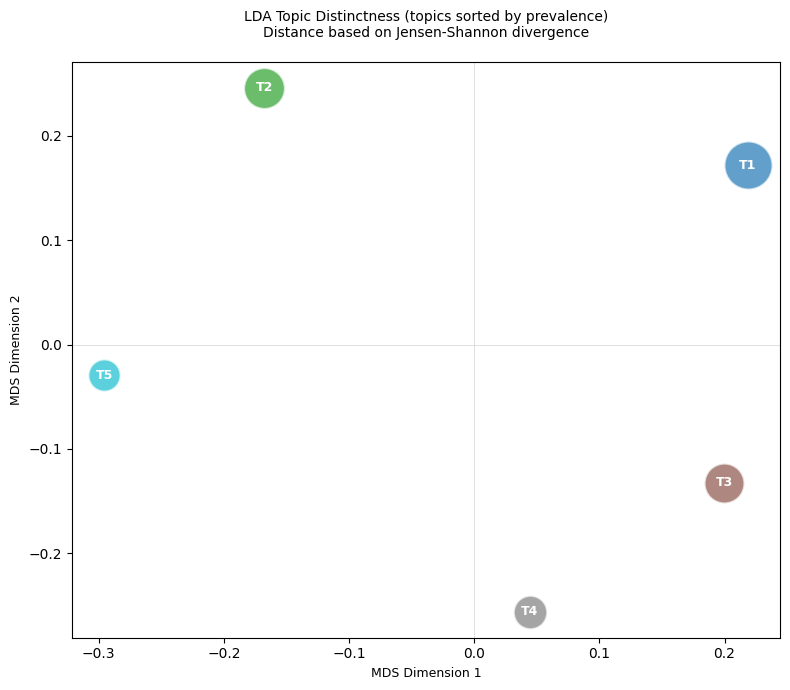

Saved → eval_results/lda_topic_distinctness_sorted.png


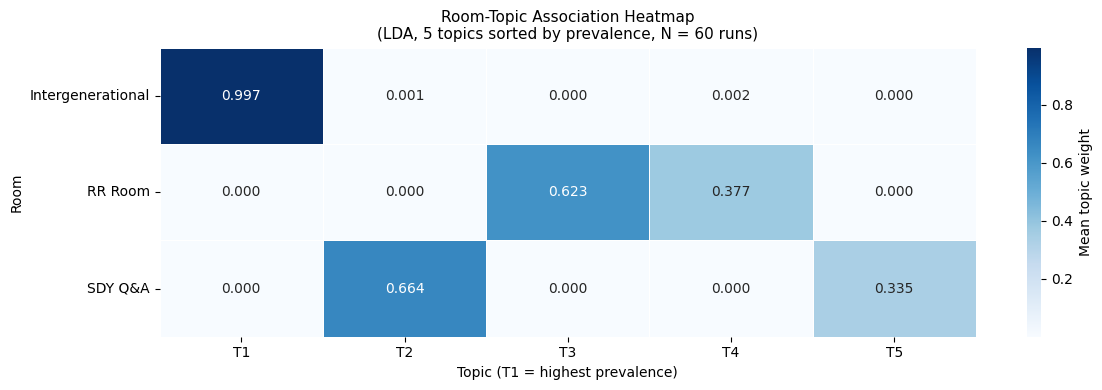

Saved → eval_results/lda_room_topic_heatmap_sorted.png
Saved → eval_results/lda_60runs_topics_sorted.csv
Saved → eval_results/lda_room_topic_weights.csv


In [ ]:
#  LDA on All 60 Simulations

!pip install -q gensim pyldavis nltk pandas numpy matplotlib seaborn scipy


import warnings
warnings.filterwarnings("ignore")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.spatial.distance import jensenshannon
from sklearn.manifold import MDS

import nltk
nltk.download("stopwords", quiet=True)
nltk.download("punkt",     quiet=True)
nltk.download("punkt_tab", quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from gensim import corpora
from gensim.models import LdaModel
plt.rcParams["font.family"] = "DejaVu Sans"


ROOMS = [
    ("Researcher vs. Red Guard",        Path("./runs/researcher_vs_redguard_t05")),
    ("Intergenerational Understanding", Path("./runs/intergenerational_t05")),
    ("User vs. Sent-Down Youth Q&A",    Path("./runs/sentdown_qa_t05")),
]

OUT_DIR        = Path("./eval_results")
OUT_DIR.mkdir(parents=True, exist_ok=True)

EXCLUDE_AGENTS = {"User", "Moderator"}
N_TOPICS       = 5
N_PASSES       = 30
RANDOM_STATE   = 42

EXTRA_STOPWORDS = {
    "would", "could", "one", "also", "even", "still", "know",
    "think", "say", "said", "like", "well", "back", "get",
    "go", "going", "went", "come", "came", "see", "saw",
    "make", "made", "take", "took", "want", "wanted",
    "tell", "told", "ask", "asked",
    "look", "looked", "let", "much", "many", "every",
    "around", "always", "never", "though", "yet", "perhaps",
    "something", "anything", "everything", "nothing",
    "someone", "anyone", "everyone", "time", "way",
    "day", "year", "years", "people", "person", "life",
    "thing", "things", "place", "part", "long", "used",
    "cultural", "revolution", "sometimes", "ever", "next",
    "away", "started", "first", "others", "sense",
    "kind", "really", "maybe", "right",
    "words", "inside", "outside", "left", "kept", "talk",
    "became", "suddenly", "behind", "might",
    "another", "else", "side", "moment", "thought", "watched","seemed",
    "got", "turned", "knew", "almost", "little", "quickly", "meant",
    "room", "redguard",
}

STOP_WORDS = set(stopwords.words("english")) | EXTRA_STOPWORDS


def load_runs(runs_dir: Path) -> list[list[dict]]:
    files = sorted(runs_dir.glob("run_*.json"))
    if not files:
        raise FileNotFoundError(f"No run_*.json files in {runs_dir}")
    runs = []
    for f in files:
        data = json.loads(f.read_text(encoding="utf-8"))
        if isinstance(data, dict):
            data = data.get("turns", data.get("messages", []))
        runs.append(data)
    return runs


def tokenize(text: str) -> list[str]:
    tokens = word_tokenize(text.lower())
    return [t for t in tokens
            if t.isalpha() and t not in STOP_WORDS and len(t) > 2]


corpus_tokens = []
room_labels   = []

for room_name, runs_dir in ROOMS:
    runs = load_runs(runs_dir)
    print(f"  {room_name}: {len(runs)} runs loaded")
    for run in runs:
        text = " ".join(
            t["text"] for t in run if t["agent"] not in EXCLUDE_AGENTS
        )
        corpus_tokens.append(tokenize(text))
        room_labels.append(room_name)

print(f"\nTotal documents: {len(corpus_tokens)}")


dictionary = corpora.Dictionary(corpus_tokens)
dictionary.filter_extremes(no_below=3, no_above=0.90)
bow_corpus  = [dictionary.doc2bow(doc) for doc in corpus_tokens]
print(f"Vocabulary size: {len(dictionary)}")

print(f"\nFitting LDA ({N_TOPICS} topics, {N_PASSES} passes) ...")
lda_model = LdaModel(
    corpus=bow_corpus,
    id2word=dictionary,
    num_topics=N_TOPICS,
    random_state=RANDOM_STATE,
    passes=N_PASSES,
    alpha="auto",
    eta="auto",
)
print("Done.")


topic_weights = np.zeros((len(bow_corpus), N_TOPICS))
for doc_idx, bow in enumerate(bow_corpus):
    for topic_id, weight in lda_model.get_document_topics(
            bow, minimum_probability=0):
        topic_weights[doc_idx, topic_id] = weight

overall_weights = topic_weights.mean(axis=0)

sorted_idx = np.argsort(overall_weights)[::-1]

print("\nTopics sorted by overall weight:")
print(f"  {'Rank':>5}  {'Weight':>8}  Top Keywords")
print("  " + "-" * 65)
for rank, i in enumerate(sorted_idx):
    words  = ", ".join([w for w, _ in lda_model.show_topic(i, topn=10)])
    weight = overall_weights[i]
    print(f"  {rank+1:>5}  {weight:>8.4f}  {words}")


n_words = len(dictionary)
topic_word_matrix = np.zeros((N_TOPICS, n_words))
for i in range(N_TOPICS):
    for word_id, prob in lda_model.get_topic_terms(i, topn=n_words):
        topic_word_matrix[i, word_id] = prob

dist_matrix = np.zeros((N_TOPICS, N_TOPICS))
for i in range(N_TOPICS):
    for j in range(N_TOPICS):
        dist_matrix[i, j] = jensenshannon(
            topic_word_matrix[i], topic_word_matrix[j]
        )

mds    = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
coords = mds.fit_transform(dist_matrix)

prevalence = overall_weights * 3000 + 200
colors     = plt.cm.tab10(np.linspace(0, 1, N_TOPICS))

fig, ax = plt.subplots(figsize=(8, 7))
for rank, i in enumerate(sorted_idx):
    ax.scatter(coords[i, 0], coords[i, 1],
               s=prevalence[i], c=[colors[rank]],
               alpha=0.7, edgecolors="white", linewidths=1.5)
    ax.annotate(
        f"T{rank+1}",
        (coords[i, 0], coords[i, 1]),
        ha="center", va="center",
        fontsize=9, fontweight="bold", color="white",
    )
ax.set_title(
    "LDA Topic Distinctness (topics sorted by prevalence)\n"
    "Distance based on Jensen-Shannon divergence\n"
    ,
    fontsize=10,
)
ax.set_xlabel("MDS Dimension 1", fontsize=9)
ax.set_ylabel("MDS Dimension 2", fontsize=9)
ax.axhline(0, color="lightgrey", linewidth=0.5)
ax.axvline(0, color="lightgrey", linewidth=0.5)
plt.tight_layout()

dist_path = OUT_DIR / "lda_topic_distinctness_sorted.png"
plt.savefig(dist_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {dist_path}")



df_weights        = pd.DataFrame(
    topic_weights,
    columns=[f"Topic {i+1}" for i in range(N_TOPICS)]
)
df_weights["room"] = room_labels
room_means         = df_weights.groupby("room").mean()

room_means.index = [
    r.replace("Researcher vs. Red Guard",        "RR Room")
     .replace("Intergenerational Understanding", "Intergenerational")
     .replace("User vs. Sent-Down Youth Q&A",    "SDY Q&A")
    for r in room_means.index
]


sorted_col_names           = [f"Topic {i+1}" for i in sorted_idx]
room_means_sorted          = room_means[sorted_col_names].copy()
room_means_sorted.columns  = [f"T{rank+1}" for rank in range(N_TOPICS)]

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(
    room_means_sorted,
    annot=True, fmt=".3f",
    cmap="Blues", ax=ax,
    linewidths=0.5,
    cbar_kws={"label": "Mean topic weight"},
)
ax.set_title(
    f"Room-Topic Association Heatmap\n"
    f"(LDA, {N_TOPICS} topics sorted by prevalence, N = 60 runs)",
    fontsize=11,
)
ax.set_xlabel("Topic (T1 = highest prevalence)", fontsize=10)
ax.set_ylabel("Room", fontsize=10)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()

heatmap_path = OUT_DIR / "lda_room_topic_heatmap_sorted.png"
plt.savefig(heatmap_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {heatmap_path}")


rows = []
for rank, i in enumerate(sorted_idx):
    words  = [w for w, _ in lda_model.show_topic(i, topn=10)]
    weight = overall_weights[i]
    rows.append({
        "rank":           rank + 1,
        "original_topic": i + 1,
        "top_keywords":   ", ".join(words),
        "overall_weight": round(float(weight), 4),
        "label":          "",   # fill in manually
    })

df_topics = pd.DataFrame(rows)
topics_csv = OUT_DIR / "lda_60runs_topics_sorted.csv"
df_topics.to_csv(topics_csv, index=False)
print(f"Saved → {topics_csv}")

room_means_sorted.to_csv(OUT_DIR / "lda_room_topic_weights.csv")
print(f"Saved → {OUT_DIR / 'lda_room_topic_weights.csv'}")